In [1]:
import pandas as pd

if_df = pd.read_csv("delhi_air_anomaly_with_iforest_train_test.csv", parse_dates=["date"])
lstm_df = pd.read_csv("delhi_air_anomaly_with_lstm_minmax_pytorch.csv", parse_dates=["date"])

merged = pd.merge(
    if_df,
    lstm_df[["date", "lstm_score", "lstm_label"]],
    on="date",
    how="inner"
)


In [2]:
merged["iforest_label"].sum(), merged["lstm_label"].sum()


(130, 181)

In [4]:
# 1) Ensure labels are boolean
merged["iforest_label_bool"] = merged["iforest_label"].astype(bool)
merged["lstm_label_bool"]    = merged["lstm_label"].astype(bool)

# 2) Now compute intersections
both = merged[ merged["iforest_label_bool"] &  merged["lstm_label_bool"] ]
only_if = merged[ merged["iforest_label_bool"] & ~merged["lstm_label_bool"] ]
only_lstm = merged[ ~merged["iforest_label_bool"] &  merged["lstm_label_bool"] ]


In [5]:
merged["iforest_label"] = merged["iforest_label"].astype(bool)
merged["lstm_label"]    = merged["lstm_label"].astype(bool)


In [6]:
print("IF anomalies:", merged["iforest_label_bool"].sum())
print("LSTM anomalies:", merged["lstm_label_bool"].sum())
print("Both:", len(both))
print("Only IF:", len(only_if))
print("Only LSTM:", len(only_lstm))


IF anomalies: 130
LSTM anomalies: 210
Both: 9
Only IF: 121
Only LSTM: 201


In [7]:
both[["date","AQI","PM2.5","fire_count_all_india","iforest_score","lstm_score"]].head()
only_if[["date","AQI","PM2.5","fire_count_all_india","iforest_score","lstm_score"]].head()
only_lstm[["date","AQI","PM2.5","fire_count_all_india","iforest_score","lstm_score"]].head()


KeyError: "['AQI', 'PM2.5'] not in index"

In [8]:
print(merged.columns)


Index(['date', 'year', 'month', 'season', 'pm2.5', 'pm10', 'no2', 'so2', 'co',
       'o3', 'temperature_celsius', 'humidity', 'wind_kph',
       'fire_count_all_india', 'pm25_7day_avg', 'pm25_7day_std',
       'pm25_deviation', 'aqi', 'aqi_bucket', 'iforest_score', 'iforest_label',
       'lstm_score', 'lstm_label', 'iforest_label_bool', 'lstm_label_bool'],
      dtype='object')


In [10]:
cols = ["date", "aqi", "pm2.5", "fire_count_all_india", "iforest_score", "lstm_score"]

both[cols].head()
only_if[cols].head()
only_lstm[cols].head()



,date,aqi,pm2.5,fire_count_all_india,iforest_score,lstm_score
0,2015-01-07,370.3,282.3,0.0,-0.082300,NaN
1,2015-01-08,230.7,315.2,0.0,-0.093315,NaN
2,2015-01-09,53.6,226.8,0.0,-0.088921,NaN
3,2015-01-10,29.9,316.8,0.0,-0.071269,NaN
4,2015-01-11,450.2,439.9,0.0,-0.041631,NaN


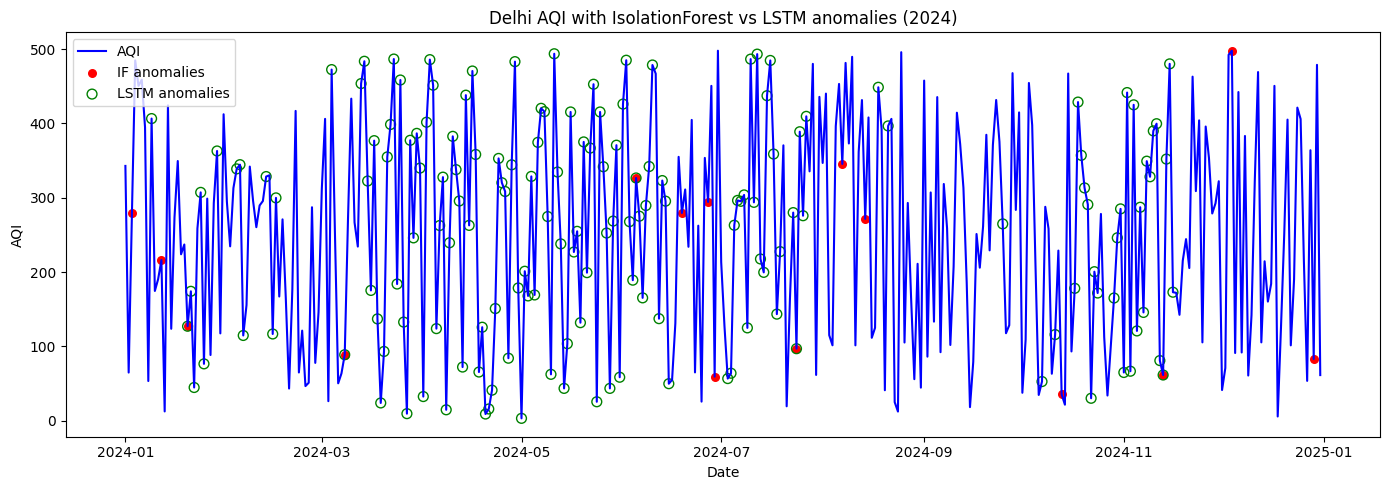

In [12]:
import matplotlib.pyplot as plt

year = 2024
sub = merged[merged["date"].dt.year == year]

plt.figure(figsize=(14,5))

# main AQI line
plt.plot(sub["date"], sub["aqi"], label="AQI", color="blue")

# IF anomalies
plt.scatter(
    sub.loc[sub["iforest_label_bool"], "date"],
    sub.loc[sub["iforest_label_bool"], "aqi"],
    color="red",
    label="IF anomalies",
    s=30
)

# LSTM anomalies
plt.scatter(
    sub.loc[sub["lstm_label_bool"], "date"],
    sub.loc[sub["lstm_label_bool"], "aqi"],
    facecolors="none",
    edgecolors="green",
    label="LSTM anomalies",
    s=50
)

plt.legend()
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title(f"Delhi AQI with IsolationForest vs LSTM anomalies ({year})")
plt.tight_layout()
plt.show()


In [13]:
n_if = merged["iforest_label_bool"].sum()
n_lstm = merged["lstm_label_bool"].sum()
n_both = len(both)
n_only_if = len(only_if)
n_only_lstm = len(only_lstm)

print("IF anomalies:", n_if)
print("LSTM anomalies:", n_lstm)
print("Both:", n_both)
print("Only IF:", n_only_if)
print("Only LSTM:", n_only_lstm)


IF anomalies: 130
LSTM anomalies: 210
Both: 9
Only IF: 121
Only LSTM: 201


In [14]:
example_both = both.sort_values("iforest_score", ascending=False).head(3)
example_if = only_if.sort_values("iforest_score", ascending=False).head(3)
example_lstm = only_lstm.sort_values("lstm_score", ascending=False).head(3)

example_both[["date","aqi","pm2.5","fire_count_all_india","temperature_celsius","wind_kph","iforest_score","lstm_score"]]


,date,aqi,pm2.5,fire_count_all_india,temperature_celsius,wind_kph,iforest_score,lstm_score
3348,2024-03-08,88.9,42.1,4125.0,23.889347,8.521909,0.021054,0.308365
3598,2024-11-13,61.6,492.3,2932.0,23.889347,8.521909,0.020783,0.314559
3486,2024-07-24,97.0,421.3,0.0,23.889347,8.521909,0.012801,0.309610


In [15]:
merged.to_csv("delhi_air_anomaly_merged_if_lstm.csv", index=False)
